# Entrenamiento de LSTM: Provincias de Loreto
**Objetivo:** Entrenar múltiples Redes Neuronales Recurrentes (LSTM), asignando un modelo independiente a cada provincia de la región Loreto para capturar su micro-comportamiento epidemiológico sin interferencia de zonas de baja incidencia.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("🚀 Iniciando Arquitectura Global para la Región Loreto...\n")

🚀 Iniciando Arquitectura Global para la Región Loreto...



## Paso 2: One-Hot Encoding / Scaler.

In [4]:
PATH_CSV = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/dataset_loreto_provincias.csv'
df_provincias = pd.read_csv(PATH_CSV)

In [5]:
# A. Codificamos el nombre de las provincias (Ej: Maynas = 0, Requena = 1)
encoder_prov = LabelEncoder()
df_provincias['id_provincia'] = encoder_prov.fit_transform(df_provincias['provincia'])
num_provincias = len(encoder_prov.classes_)
print(f"📍 Provincias unificadas ({num_provincias}): {list(encoder_prov.classes_)}")

📍 Provincias unificadas (8): ['ALTO AMAZONAS', 'DATEM DEL MARA�ON', 'LORETO', 'MARISCAL RAMON CASTILLA', 'MAYNAS', 'PUTUMAYO', 'REQUENA', 'UCAYALI']


In [6]:
# B. Escalamos los Casos (Un solo scaler para todo Loreto)
scaler_casos = MinMaxScaler(feature_range=(0, 1))
casos_escalados = scaler_casos.fit_transform(df_provincias[['total_casos']])

In [7]:
# C. One-Hot Encoding de las Provincias
provincias_ohe = to_categorical(df_provincias['id_provincia'], num_classes=num_provincias)

In [8]:
# D. Fusionamos: [Casos Escaldos + Columnas OHE de Provincia]
data_combinada = np.hstack((casos_escalados, provincias_ohe))
print(f"📊 Matriz combinada: 1 columna de casos + {num_provincias} de geografía.")

📊 Matriz combinada: 1 columna de casos + 8 de geografía.


##Paso 3: CONSTRUCCIÓN DE TENSORES (SPLITTING)

In [47]:
TIME_STEPS = 6
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

print("Procesando ventanas de tiempo provincia por provincia...")

Procesando ventanas de tiempo provincia por provincia...


In [48]:
for prov_id in sorted(df_provincias['id_provincia'].unique()):
    # Filtramos la historia exacta de esta provincia
    indices_prov = df_provincias[df_provincias['id_provincia'] == prov_id].index
    bloque_prov = data_combinada[indices_prov]

    # DIVISIÓN CRONOLÓGICA (85% Pasado / 15% Futuro)
    split_idx = int(len(bloque_prov) * 0.85)
    train_prov = bloque_prov[:split_idx]
    test_prov = bloque_prov[split_idx:]

    # Armamos secuencias TRAIN
    for i in range(len(train_prov) - TIME_STEPS):
        X_train_list.append(train_prov[i:(i + TIME_STEPS)])
        y_train_list.append(train_prov[i + TIME_STEPS, 0]) # Solo predecimos los casos (columna 0)

    # Armamos secuencias TEST
    for i in range(len(test_prov) - TIME_STEPS):
        X_test_list.append(test_prov[i:(i + TIME_STEPS)])
        y_test_list.append(test_prov[i + TIME_STEPS, 0])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

print(f"✅ Tensor X_train listo: {X_train.shape} -> [Muestras, Semanas, Variables]")

✅ Tensor X_train listo: (4903, 6, 9) -> [Muestras, Semanas, Variables]


## Paso 4: RED NEURONAL

In [49]:
modelo_global = Sequential([
    # Input shape: 2 semanas, (1 + num_provincias) variables
    LSTM(64, activation='relu', return_sequences=True, input_shape=(TIME_STEPS, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
modelo_global.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008), loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

##Paso 5: Entrenamiento

In [51]:
print("\nIniciando entrenamiento del Super Modelo de Loreto...")
historial = modelo_global.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Iniciando entrenamiento del Super Modelo de Loreto...
Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0058 - val_loss: 0.0010
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0024 - val_loss: 9.9361e-04
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0022 - val_loss: 0.0010
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0021 - val_loss: 9.7309e-04
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0020 - val_loss: 9.6434e-04
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0020 - val_loss: 9.2509e-04
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 9.4148e-04
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 8.7426e-04
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8m

## Paso 6: EVALUACIÓN Y MÉTRICAS

In [52]:
pred_scaled = modelo_global.predict(X_test)
y_pred_real = scaler_casos.inverse_transform(pred_scaled)
y_test_real = scaler_casos.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("\n" + "="*50)
print(" 🏆 RENDIMIENTO GLOBAL - REGIÓN LORETO 🏆")
print("="*50)
print(f"MAE Global: {mae:.2f} casos de margen de error promedio")
print(f"R2 Score Global: {r2:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

 🏆 RENDIMIENTO GLOBAL - REGIÓN LORETO 🏆
MAE Global: 16.87 casos de margen de error promedio
R2 Score Global: 0.8570


##PASO 8: GRAFICA COMPARATIVA

In [53]:
PROVINCIA_TEST = 'MAYNAS'
print(f"Generando gráfico de rendimiento en tiempo real para: {PROVINCIA_TEST}...")

Generando gráfico de rendimiento en tiempo real para: MAYNAS...


In [54]:
# 1. Filtramos y reconstruimos la historia exacta de Maynas
id_prov_test = encoder_prov.transform([PROVINCIA_TEST])[0]
indices_test = df_provincias[df_provincias['id_provincia'] == id_prov_test].index
bloque_test = data_combinada[indices_test]

In [55]:
# 2. Extraemos solo su bloque de Test (el último 15% del tiempo que la IA no ha estudiado)
split_idx = int(len(bloque_test) * 0.85)
test_data_prov = bloque_test[split_idx:]

In [56]:
# 3. Armamos las ventanas de memoria de 2 semanas
X_plot, y_plot_real = [], []
for i in range(len(test_data_prov) - TIME_STEPS):
    X_plot.append(test_data_prov[i:(i + TIME_STEPS)])
    y_plot_real.append(test_data_prov[i + TIME_STEPS, 0])

X_plot = np.array(X_plot)

In [57]:
# 4. Hacemos que la IA prediga todo este segmento
pred_plot_scaled = modelo_global.predict(X_plot, verbose=0)

In [58]:
# 5. Invertimos el escalado
y_plot_real_inv = scaler_casos.inverse_transform(np.array(y_plot_real).reshape(-1, 1))
pred_plot_inv = scaler_casos.inverse_transform(pred_plot_scaled)

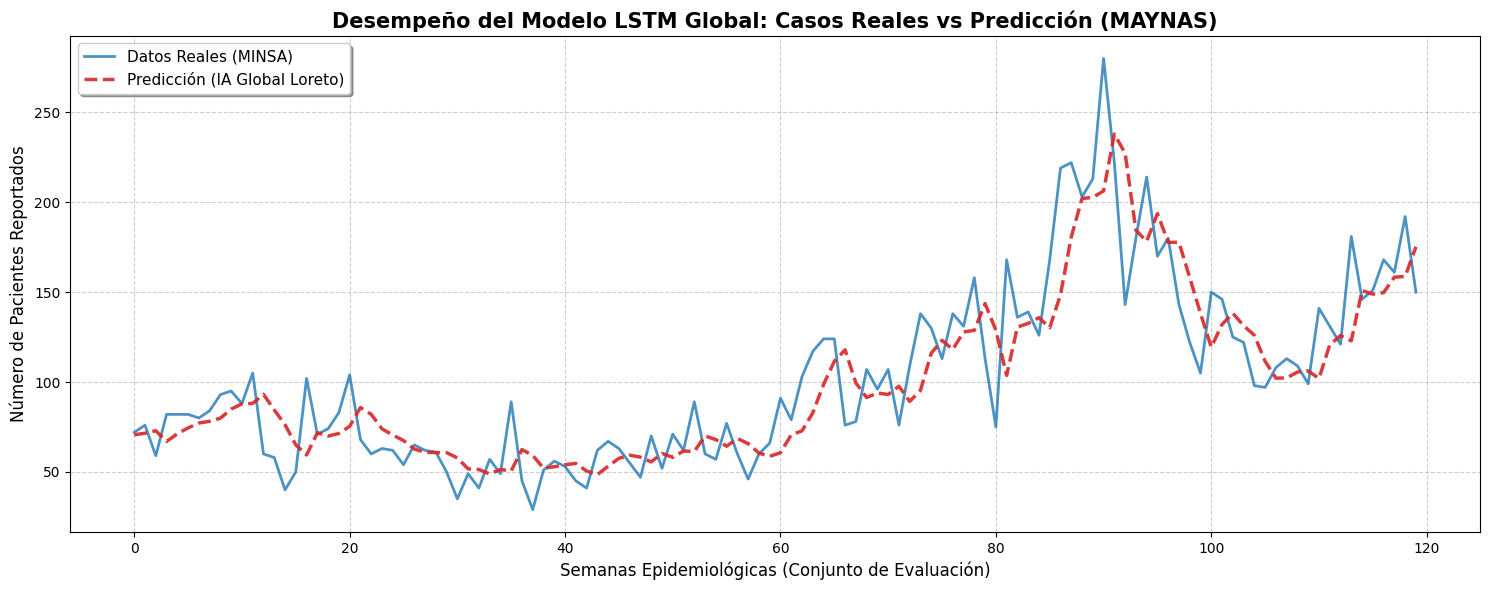

In [59]:
# 6. GRAFICAMOS
plt.figure(figsize=(15, 6))
plt.plot(y_plot_real_inv, label='Datos Reales (MINSA)', color='#1f77b4', linewidth=2, alpha=0.8)
plt.plot(pred_plot_inv, label='Predicción (IA Global Loreto)', color='#d62728', linestyle='--', linewidth=2.5, alpha=0.9)

plt.title(f'Desempeño del Modelo LSTM Global: Casos Reales vs Predicción ({PROVINCIA_TEST})', fontsize=15, fontweight='bold')
plt.xlabel('Semanas Epidemiológicas (Conjunto de Evaluación)', fontsize=12)
plt.ylabel('Número de Pacientes Reportados', fontsize=12)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# PASO 9: PROYECCIÓN AL FUTURO (2025) - PREDICCIÓN RECURSIVA

🔮 Procesando modelo de 12 semanas para MAYNAS...


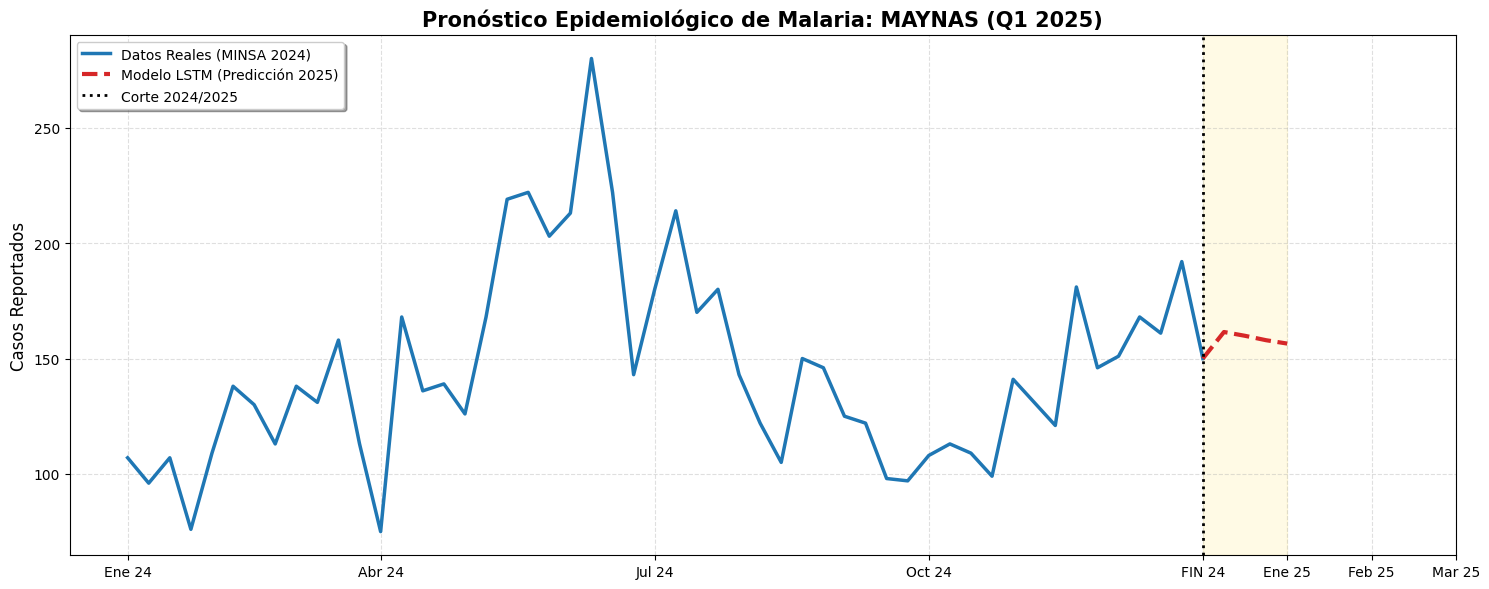


📊 Resultados exactos para MAYNAS (Primeras 12 semanas de 2025):
[161 160 158 156]


In [63]:
PROVINCIA_TARGET = 'MAYNAS'
SEMANAS_PROYECCION = 4  # Futuro: Pronosticamos el Q1 de 2025

print(f"🔮 Procesando modelo de 12 semanas para {PROVINCIA_TARGET}...")

id_prov = encoder_prov.transform([PROVINCIA_TARGET])[0]
vector_ohe = to_categorical(id_prov, num_classes=num_provincias)

data_provincia = data_combinada[df_provincias['id_provincia'] == id_prov]
ventana_actual = data_provincia[-TIME_STEPS:].copy()

predicciones_escaladas = []

for _ in range(SEMANAS_PROYECCION):
    pred_scaled = modelo_global.predict(ventana_actual[np.newaxis, ...], verbose=0)[0, 0]
    predicciones_escaladas.append(pred_scaled)

    nuevo_registro = np.concatenate(([pred_scaled], vector_ohe))
    ventana_actual = np.vstack((ventana_actual[1:], nuevo_registro))

pred_futuro = scaler_casos.inverse_transform(np.array(predicciones_escaladas).reshape(-1, 1)).flatten()


ultimos_reales = df_provincias[df_provincias['provincia'] == PROVINCIA_TARGET]['total_casos'].tail(52).values

eje_x_real = range(1, 53)
eje_x_pred = range(52, 52 + SEMANAS_PROYECCION + 1)
linea_pred = np.concatenate(([ultimos_reales[-1]], pred_futuro))

plt.figure(figsize=(15, 6))

plt.plot(eje_x_real, ultimos_reales, label='Datos Reales (MINSA 2024)', color='#1f77b4', linewidth=2.5)
plt.plot(eje_x_pred, linea_pred, label='Modelo LSTM (Predicción 2025)', color='#d62728', linestyle='--', linewidth=3)

plt.axvline(x=52, color='black', linestyle=':', linewidth=2, label='Corte 2024/2025')
plt.axvspan(52, 52 + SEMANAS_PROYECCION, color='gold', alpha=0.1) # Sombreado de zona futura

plt.title(f'Pronóstico Epidemiológico de Malaria: {PROVINCIA_TARGET} (Q1 2025)', fontsize=15, fontweight='bold')
plt.ylabel('Casos Reportados', fontsize=12)

pos_x = [1, 13, 26, 39, 52, 56, 60, 64]
lab_x = ['Ene 24', 'Abr 24', 'Jul 24', 'Oct 24', 'FIN 24', 'Ene 25', 'Feb 25', 'Mar 25']
plt.xticks(ticks=pos_x, labels=lab_x)

plt.legend(loc='upper left', shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\n📊 Resultados exactos para {PROVINCIA_TARGET} (Primeras 12 semanas de 2025):")
print(np.round(pred_futuro).astype(int))

In [66]:
import pickle
from google.colab import files

In [64]:
modelo_global.save('lstm_loreto_global.keras')
print("✅ Modelo .keras guardado.")

✅ Modelo .keras guardado.


In [67]:
with open('scaler_casos_loreto.pkl', 'wb') as f:
    pickle.dump(scaler_casos, f)
print("✅ Escalador de casos guardado.")

✅ Escalador de casos guardado.


In [68]:
with open('encoder_provincias.pkl', 'wb') as f:
    pickle.dump(encoder_prov, f)
print("✅ Codificador de provincias guardado.")

✅ Codificador de provincias guardado.


In [69]:
print("\nIniciando descargas...")
files.download('lstm_loreto_global.keras')
files.download('scaler_casos_loreto.pkl')
files.download('encoder_provincias.pkl')


Iniciando descargas...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>